# Loan Default Prediction
## Predicting Loan Default Using Logistic Regression

**Objective:** Build a classification model to predict the probability 
of a borrower defaulting on a loan based on demographic characteristics 
and loan profile.

**Dataset:** Credit Risk Dataset from Kaggle  
**Target Variable:** `loan_status` (0 = Non-Default, 1 = Default)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scorecardpy as sc

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading

In [ ]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nClass distribution:\n{df['loan_status'].value_counts()}")
print(f"\nDefault rate: {df['loan_status'].mean()*100:.2f}%")

Total rows: 32581
Total columns: 12

Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Class distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Default rate: 21.82%


**Key Observations:**
- Dataset contains 32,581 rows and 12 columns
- Missing values detected: `person_emp_length` (895 rows, 2.7%) and `loan_int_rate` (3,116 rows, 9.6%)
- Class imbalance: 78.18% non-default vs 21.82% default
- Imbalanced dataset → `class_weight='balanced'` will be applied in the model to prevent bias toward majority class

## 2. Data Cleaning

### 2.1 Handling Missing Values

Based on initial inspection, two columns contain missing values:
- `person_emp_length`: 895 rows 
- `loan_int_rate`: 3,116 rows

Both columns are imputed with median because median is more robust against outliers compared to mean.

In [4]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

In [5]:
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

This section explores the dataset to understand feature distributions, 
identify potential data errors, outliers, and the relationship between 
each feature and the target variable `loan_status`.

### 3.1 Feature Overview

Before exploring the data, we first identify which features are 
numerical and which are categorical based on their data types.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
# Separate numerical and categorical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target variable from num_cols
num_cols.remove('loan_status')

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")

Numerical features (7): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical features (4): ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


### 3.2 Distribution of Numerical Features

Histogram plots to examine the distribution of each numerical feature 
and identify skewness or abnormal values.

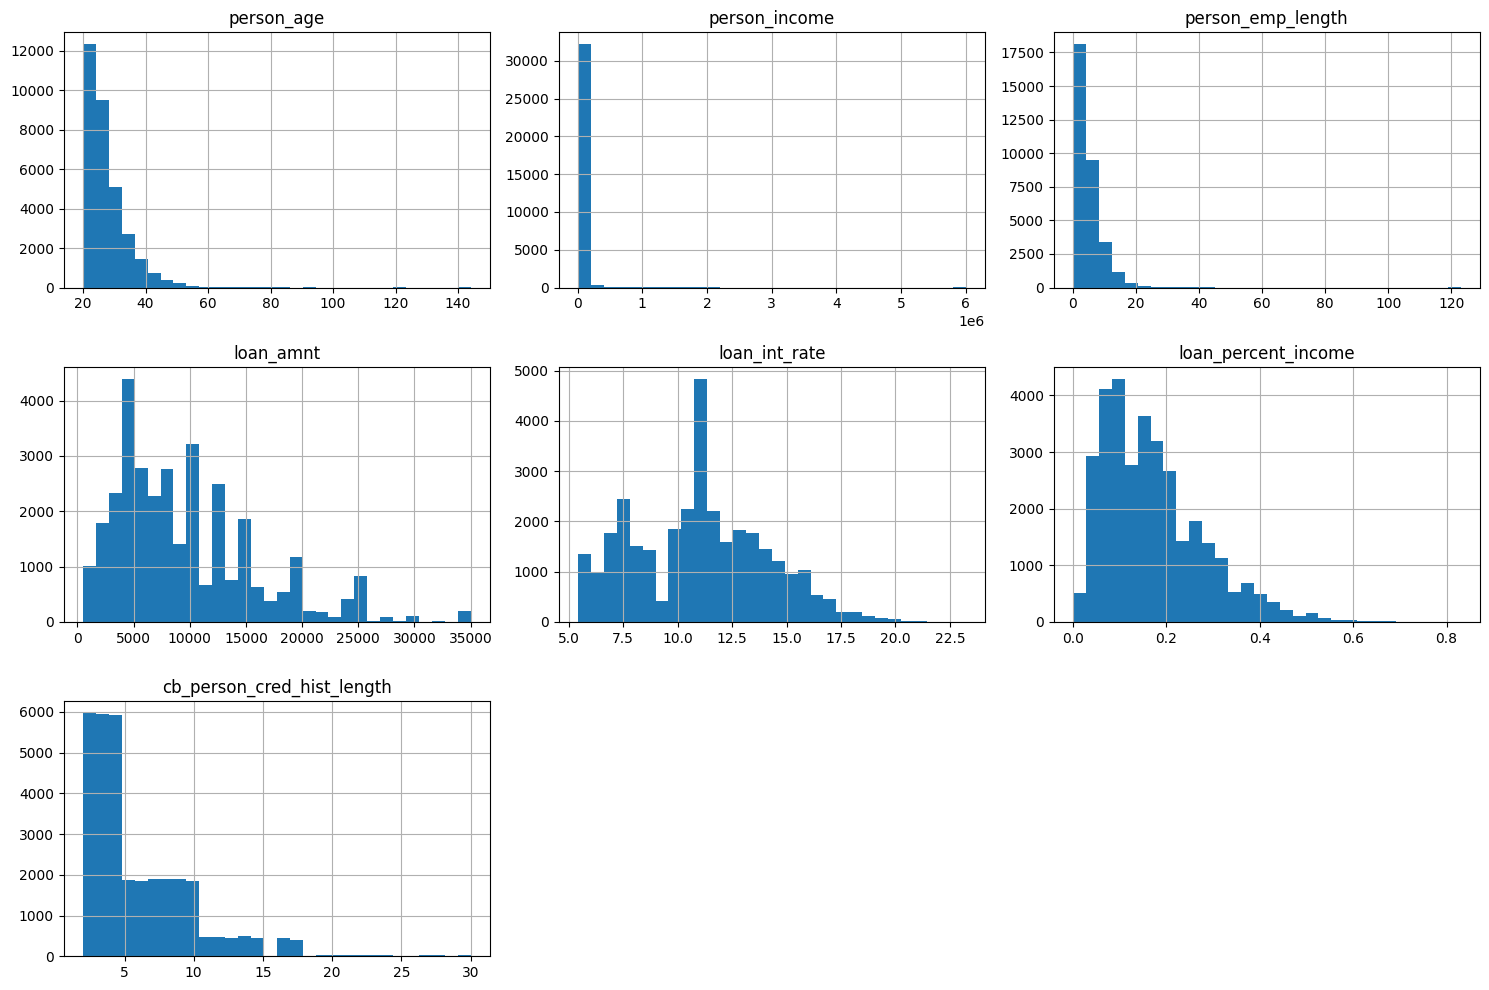

In [8]:
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

**Observations:**
- All numerical features show right-skewed distributions
- `person_age` contains values up to 140 — physically impossible, likely data error
- `person_emp_length` contains values up to 120 — physically impossible, likely data error  
- `person_income` contains extreme values up to 6 million — possible outlier, needs further

### 3.3 Outlier Detection via Boxplot

Boxplots to visualize the spread of each numerical feature and 
confirm the presence of outliers identified in the histogram.

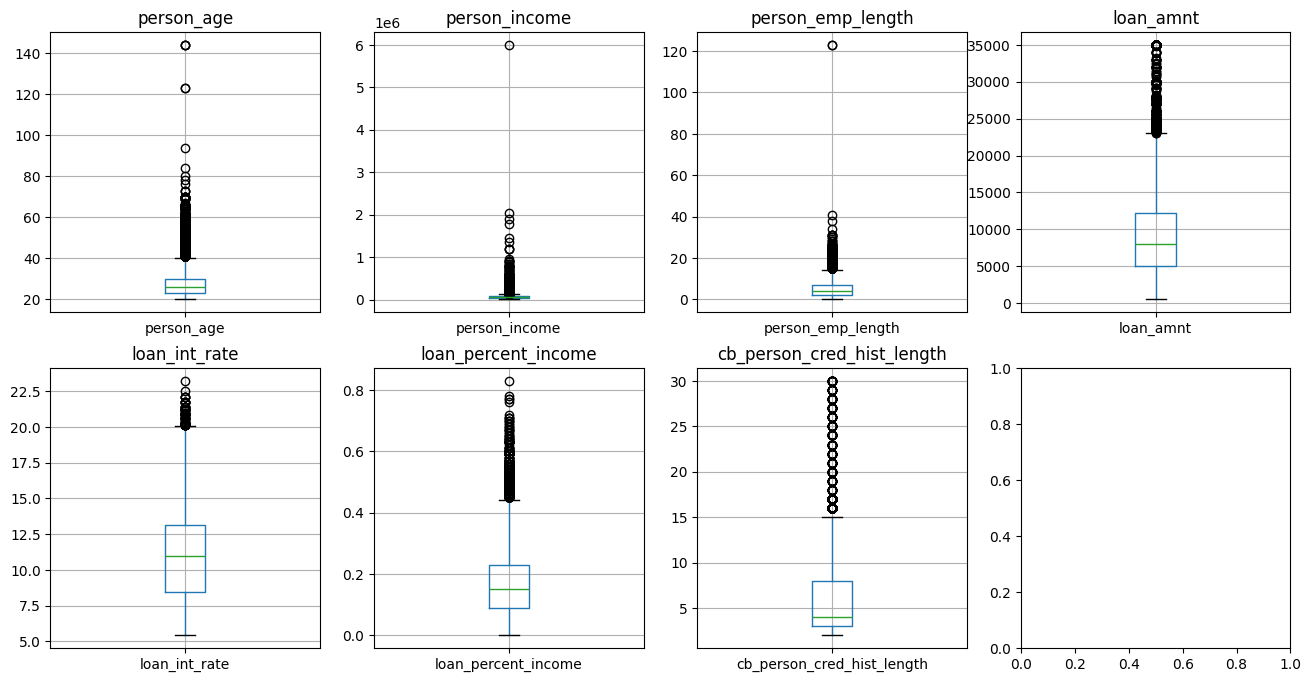

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.show()

**Observations:**
- `person_age`: values above 100 detected and will be removed as data error
- `person_emp_length`: values above 100 detected and will be removed as data error
- `person_income`: extreme values up to 6 million detected, representing ~1% of data.
- Other features show outliers within acceptable and realistic ranges and will be retained as-is.

### 3.4 Numerical Features vs Target Variable

Boxplots comparing feature distributions between default (1) and 
non-default (0) borrowers to identify features with strong 
discriminatory power.

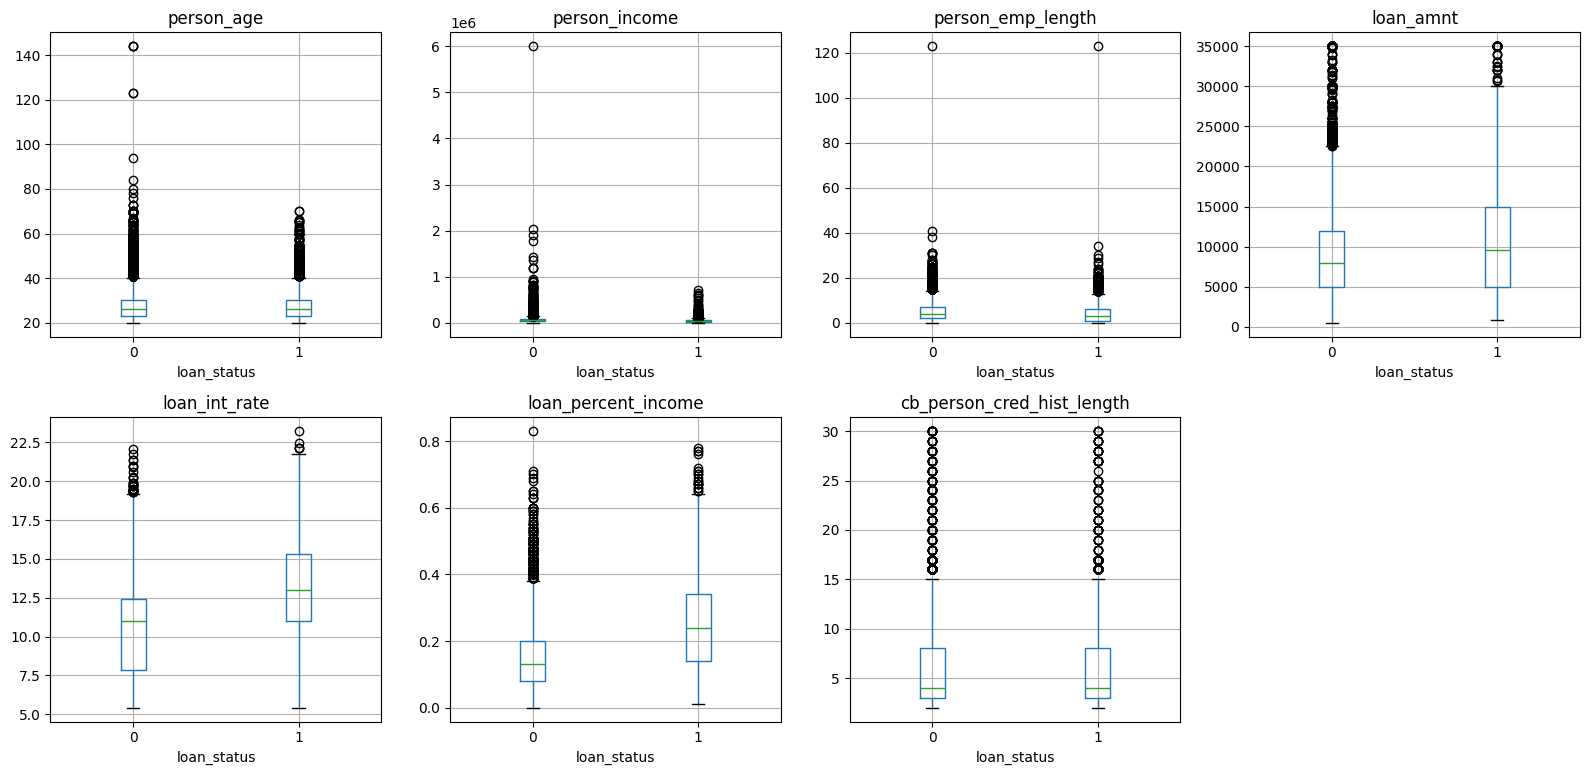

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='loan_status', ax=axes[i])
    axes[i].set_title(col)

axes[-1].set_visible(False)
plt.suptitle('')
plt.tight_layout()
plt.show()

**Observations:**
- `loan_int_rate` and `loan_percent_income` show clear upward shift 
  in median for default class compared to non-default class. These feautures are indicating strong predictor
- Remaining features show minimal difference in distribution between 
  classes indicating. However, it will be confirmed by IV analysis

### 3.5 Default Rate by Categorical Features

Bar charts showing the default rate per category to identify which 
categorical values are associated with higher default risk.

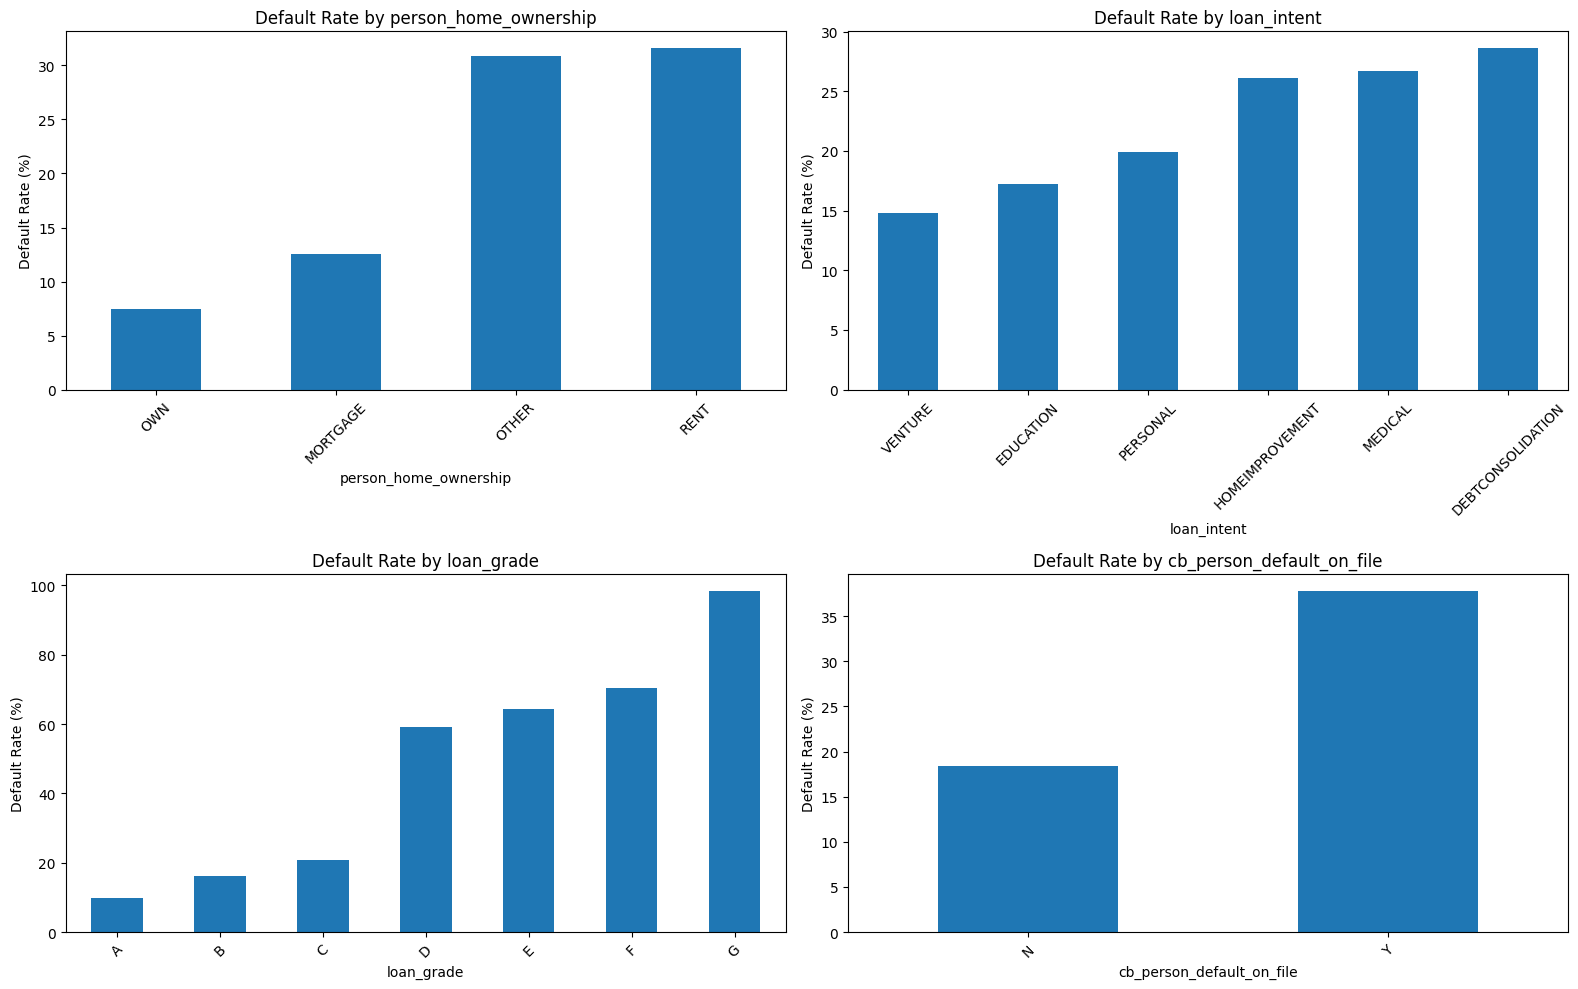

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)['loan_status'].mean() * 100
    default_rate.sort_values().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observations:**
- `loan_grade`: default rate increases consistently from grade A (about 10%) 
  to grade G (about 98%) — the higher the grade letter, the higher the default 
  risk. However, this pattern is suspiciously strong and may indicate 
  that loan grade was assigned based on payment behavior. This will be investigated further in 
  feature selection.
- `person_home_ownership`: OWN (about 7.5%) shows significantly lower default 
  rate than RENT (about 31.5%) while home ownership is a strong risk indicator
- `cb_person_default_on_file`: borrowers with a prior default record (Y) 
  show a significantly higher default rate (about 37.5%) compared to those 
  without (about 18.5%)
- `loan_intent`: DEBTCONSOLIDATION (about 28.5%) and MEDICAL (about 26.5%) show 
  the highest default rates, while VENTURE (about 15%) shows the lowest
- `person_home_ownership`: OWN (7.5%) shows the lowest default rate 
  while RENT (31.5%) and OTHER (31%) show similarly high default rates. 
  However, the category OTHER is ambiguous as the dataset does not 
  provide a clear definition of what it represents. Given this ambiguity, 
  `person_home_ownership` will be dropped in feature selection.

## 4. Feature Engineering & Preprocessing

This section covers all steps taken to prepare the data for modelling:
1. Dropping features
2. Feature selection using Information Value (IV)
3. Train-test split
4. WoE Transformation

### 4.1 Dropping Features Based on EDA Findings and domain reasoning :

The following features are dropped before IV analysis based on EDA findings and domain reasoning:

**`person_home_ownership`**  the 'Other' category has no clear definition in the dataset documentation which making it ambiguous to interpret.

**`loan_int_rate`**  interest rates are typically set by lenders based on the borrower's risk profile. Including this feature could mean the model is learning from information that already reflects the outcome it is trying to predict.

**`person_age`**  boxplot analysis in EDA revealed values above 100, which are physically impossible and confirmed as data errors. Rows with these values are removed.

**`person_emp_length`**  similarly, values above 100 were identified as data errors in EDA and removed.

Note: `person_age` and `person_emp_length` involve row-level removal of data errors, while `person_home_ownership` and `loan_int_rate` involve dropping the entire column from the feature set.

In [12]:
# Drop features
col_tobe_dropped = (df['person_age'] > 100) | (df['person_emp_length'] > 100)
df = df[~col_tobe_dropped].reset_index(drop=True)
df = df.drop(columns=['person_home_ownership', 'loan_int_rate'])

print(f"Rows remaining after removing data errors: {len(df)}")
print(f"Remaining columns: {df.columns.tolist()}")

Rows remaining after removing data errors: 32574
Remaining columns: ['person_age', 'person_income', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


### 4.2. Feature Selection

### 4.2.1 Information Value (IV) Analysis

Information Value measures how well each feature separates defaulters 
from non-defaulters.

IV thresholds:
- Below 0.02: Not useful
- 0.02 - 0.1: Weak
- 0.1 - 0.3: Medium
- 0.3 - 0.5: Strong
- Above 0.5: Suspiciously strong — investigate for potential data leakage

In [13]:
bins = sc.woebin(df, y='loan_status')

iv_values = {col: bins[col]['bin_iv'].sum() for col in bins}
iv_df = pd.DataFrame(list(iv_values.items()), columns=['Variable', 'IV'])
iv_df = iv_df.sort_values('IV', ascending=False)
print(iv_df)

[INFO] creating woe binning ...
                     Variable        IV
3         loan_percent_income  0.928945
6                  loan_grade  0.851446
2               person_income  0.507301
0   cb_person_default_on_file  0.163760
4                 loan_intent  0.091628
5                   loan_amnt  0.080197
8           person_emp_length  0.057969
1                  person_age  0.009967
7  cb_person_cred_hist_length  0.004276


### 4.2.2 Checking Data Leakage

`loan_grade` shows an IV of 0.852 which is suspiciously high. 
Combined with the finding from EDA that the dataset does not clearly 
describe how loan_grade was assigned, this raises a data leakage concern.

**Decision: Drop `loan_grade`** to avoid potential data leakage that will affect model performance

In [14]:
df = df.drop(columns=['loan_grade'])
print(f"Remaining columns: {df.columns.tolist()}")

Remaining columns: ['person_age', 'person_income', 'person_emp_length', 'loan_intent', 'loan_amnt', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


**Note :** `loan_percent_income` is retained with the consideration that the information is legitimately available before default prediction is known

**Observations:**
- `loan_percent_income` (0.929) and `loan_grade` (0.852) show 
  suspiciously high IV. This indicates potential data leakage
- `person_income` (0.508) show strong IV
- `person_age` (0.010) and `cb_person_cred_hist_length` (0.004) 
  show near-zero IV. This indicates as weak predictors

### 4.2.3 Dropping Weak Predictors

Features with IV < 0.02 are considered not useful and will be dropped.

In [15]:
# Drop features with IV < 0.02
weak_features = iv_df[iv_df['IV'] < 0.02]['Variable'].tolist()
print(f"Features to drop (IV < 0.02): {weak_features}")

df = df.drop(columns=weak_features)
print(f"\nRemaining columns: {df.columns.tolist()}")

Features to drop (IV < 0.02): ['person_age', 'cb_person_cred_hist_length']

Remaining columns: ['person_income', 'person_emp_length', 'loan_intent', 'loan_amnt', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file']


### 4.3 Train-Test Split

Data is split into 80% training and 20% test set.

In [16]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['loan_status'])


### 4.4 WoE Transformation

Before modelling, all features are transformed using Weight of Evidence (WoE). This replaces each feature's original values with a score that reflects how strongly that value is associated with default risk,making it a more suitable input for Logistic Regression.
A positive WoE value indicates higher default risk for that bin, while a negative value indicates lower default risk.

In [17]:
bins_final = sc.woebin(train_df, y='loan_status')
train_woe = sc.woebin_ply(train_df, bins_final)
test_woe  = sc.woebin_ply(test_df, bins_final)
X_train = train_woe.drop(columns=['loan_status'])
y_train = train_woe['loan_status']
X_test = test_woe.drop(columns=['loan_status'])
y_test = test_woe['loan_status']

[INFO] creating woe binning ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...


## 5. Modelling

Logistic Regression is selected as the classification model for the 
following reasons:
- Interpretable coefficients — allows understanding of feature impact 
  on default probability
- Suitable for binary classification with imbalanced dataset when 
  combined with `class_weight='balanced'`
- Computationally efficient for the dataset size

### 5.1 Model Training

In [18]:
LR = LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42)
LR.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


### 5.2 Model Evaluation

In [19]:
yhat = LR.predict(X_test)
yhat_prob = LR.predict_proba(X_test)

print(classification_report(y_test, yhat))
print(f"ROC-AUC: {roc_auc_score(y_test, yhat_prob[:,1]):.4f}")

              precision    recall  f1-score   support

           0       0.90      0.79      0.84      5094
           1       0.48      0.69      0.56      1421

    accuracy                           0.77      6515
   macro avg       0.69      0.74      0.70      6515
weighted avg       0.81      0.77      0.78      6515

ROC-AUC: 0.8148


**Model Evaluation Results:**

- **ROC-AUC: 0.8148**  the model shows strong ability to distinguish between borrowers who default and those who do not
- **Recall (Default): 0.69**  the model correctly flags 69% of actual default. In credit risk, missing a default is more costly than a false alarm, so recall is prioritized
- **Precision (Default): 0.48**  of all borrowers flagged as default, 48% actually defaulted. The lower precision is a known trade-off when using `class_weight='balanced'` on an imbalanced dataset

### 5.3 Confusion Matrix

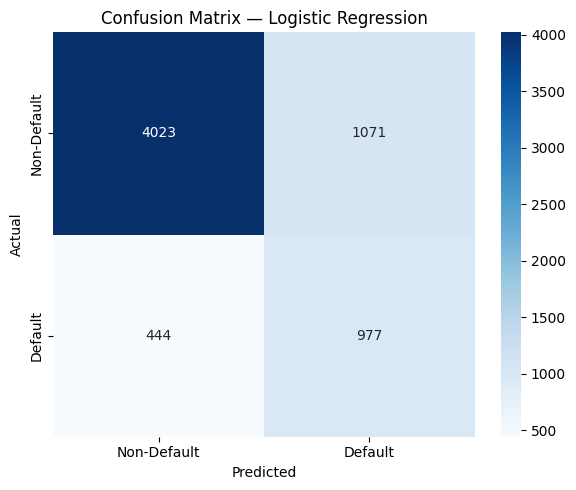

In [20]:
cm = confusion_matrix(y_test, yhat)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Non-Default', 'Default'],yticklabels=['Non-Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

The confusion matrix breaks down model predictions into four categories:

- **True Negative (4,023)** : borrowers correctly predicted as non-default
- **False Positive (1,071)** : non-defaulters incorrectly flagged as default
- **False Negative (444)** : actual defaulters missed by the model
- **True Positive (977)** : defaulters correctly identified

In credit risk, False Negatives are the most costly outcome. Approving a loan for a borrower who will default carries a higher financial risk than rejecting a borrower who would have repaid.

### 5.4 Feature Importance 

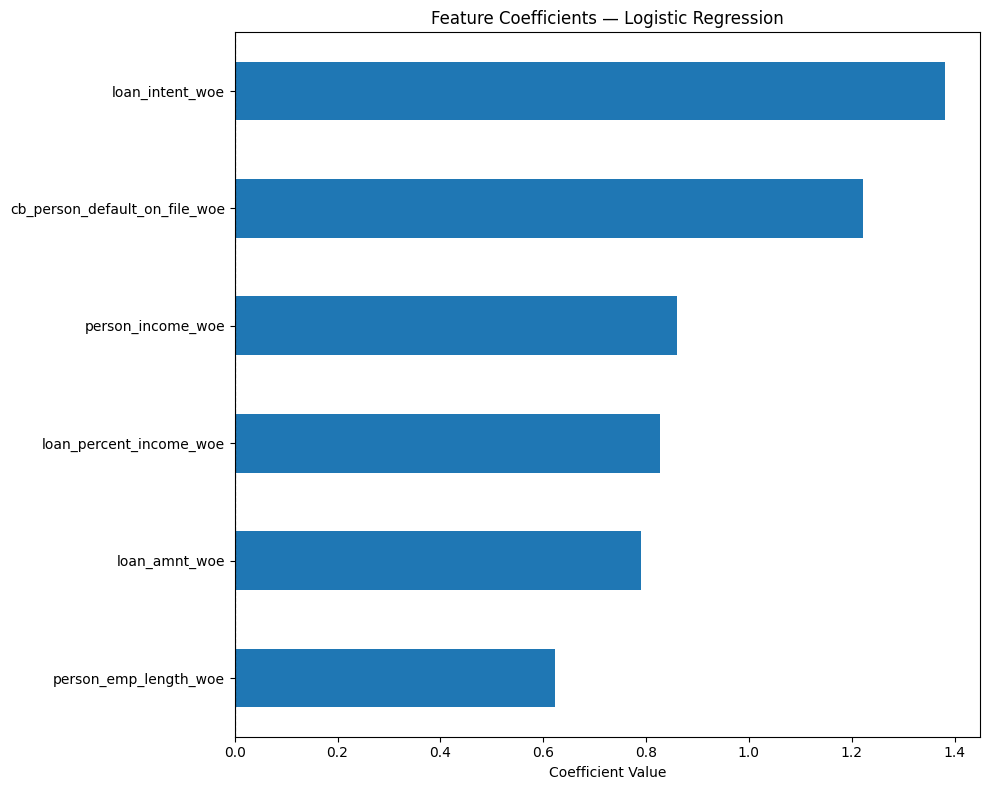

In [21]:
feature_cols = X_train.columns.tolist()

coefficients = pd.Series(LR.coef_[0], index=feature_cols)
coefficients_sorted = coefficients.sort_values()

plt.figure(figsize=(10, 8))
coefficients_sorted.plot(kind='barh')
plt.title('Feature Coefficients — Logistic Regression')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### 5.5 Plot WoE Bin for Categorical Features

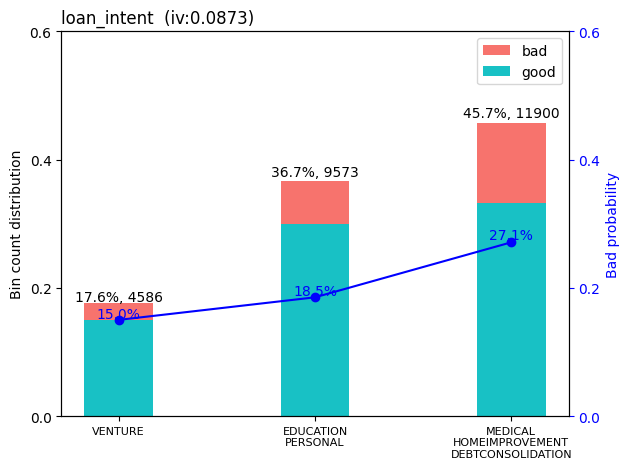

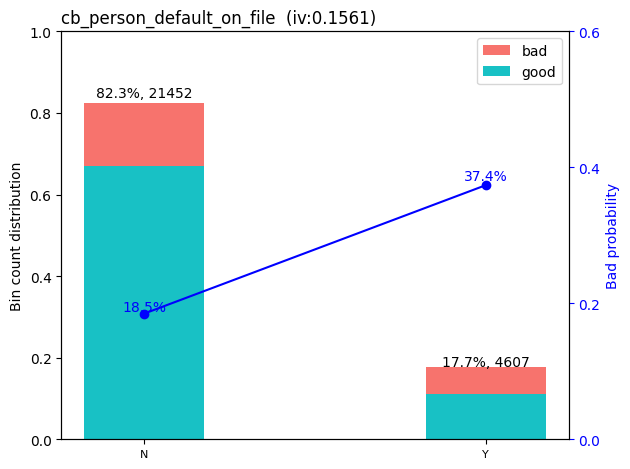

In [22]:
cat_features = ['loan_intent', 'cb_person_default_on_file']

for col in cat_features:
    plot_dict = sc.woebin_plot(bins_final[col])
    fig = plot_dict[col]
    
    for ax in fig.axes:
        labels = [label.get_text().replace('%,%', '\n') for label in ax.get_xticklabels()]
        ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=8)
    
    fig.tight_layout()
    plt.show()

#### WoE Binning Analysis
##### loan_intent 
- **VENTURE** has the lowest bad rate at 15%
- **EDUCATION, HOME IMPROVEMENT, PERSONAL** around 18.5%, close to the overall default rate — no strong directional risk signal.
- **MEDICAL and DEBT CONSOLIDATION** carry the highest bad rate at 27.1%.This is consistent with EDA findings
##### cb_person_default_on_file
- **No prior default (N)** borrowers have an 18.5% bad rate,below the overall dataset average.
- **Prior default (Y)** borrowers have a 37.4% bad rate **roughly twice** that of clean borrowers.

## 6. Conclusion

### 6.1 Summary

This project built a Logistic Regression model to predict loan default using a credit risk dataset from Kaggle.

**Data Cleaning**
Two features with impossible values were removed. `person_age` above 100 and `person_emp_length` beyond a realistic range. `person_home_ownership` was also dropped because the 'Other' category had no clear definition in the dataset documentation.

**Feature Selection**
`loan_grade` was removed because the dataset does not explain how the grade was assigned, and its unusually high IV raised concerns about data leakage. `loan_int_rate` was dropped because interest rates are typically determined by the lender based on the borrower's risk profile — including it could mean the model is learning from information that already reflects the outcome it is trying to predict. `person_age` and `cb_person_cred_hist_length` were removed due to near-zero IV, supported by minimal class separation observed in EDA.

**WoE Transformation**
Before modelling, all remaining features were transformed using Weight of Evidence. This helps Logistic Regression by ensuring each feature has a linear relationship with the log-odds of default. It also handles categorical features directly without one-hot encoding, and naturally reduces the influence of outliers through binning.

**Model Performance**
The model achieved a ROC-AUC of 0.81, meaning it can reliably distinguish between borrowers who will default and those who will not. It correctly identified 68% of actual defaulters (recall). 

### 6.2 Limitations

- The dataset does not describe how `loan_grade` was assigned, making it difficult to determine whether it could have been a legitimate predictor
- WoE binning was done using default settings. However in practice, each bin would typically be reviewed manually to ensure the pattern makes business sense
- The model was not benchmarked against other algorithms
- No cross-validation: Model performance was evaluated on a single train-test split. Without cross-validation, it is difficult to confirm whether the reported ROC-AUC of 0.8148 is stable or sensitive to how the data was divided.

### 6.3 Future Improvements

- Review WoE binning manually to ensure business interpretability per feature
- Apply cross-validation for more robust model evaluation